=== COLUMNS LOADED ===
['Unnamed: 0', 'Database', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']

Shape: (362, 30)

Dropped 17 sparse columns. Remaining: 13
Columns used:
['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']


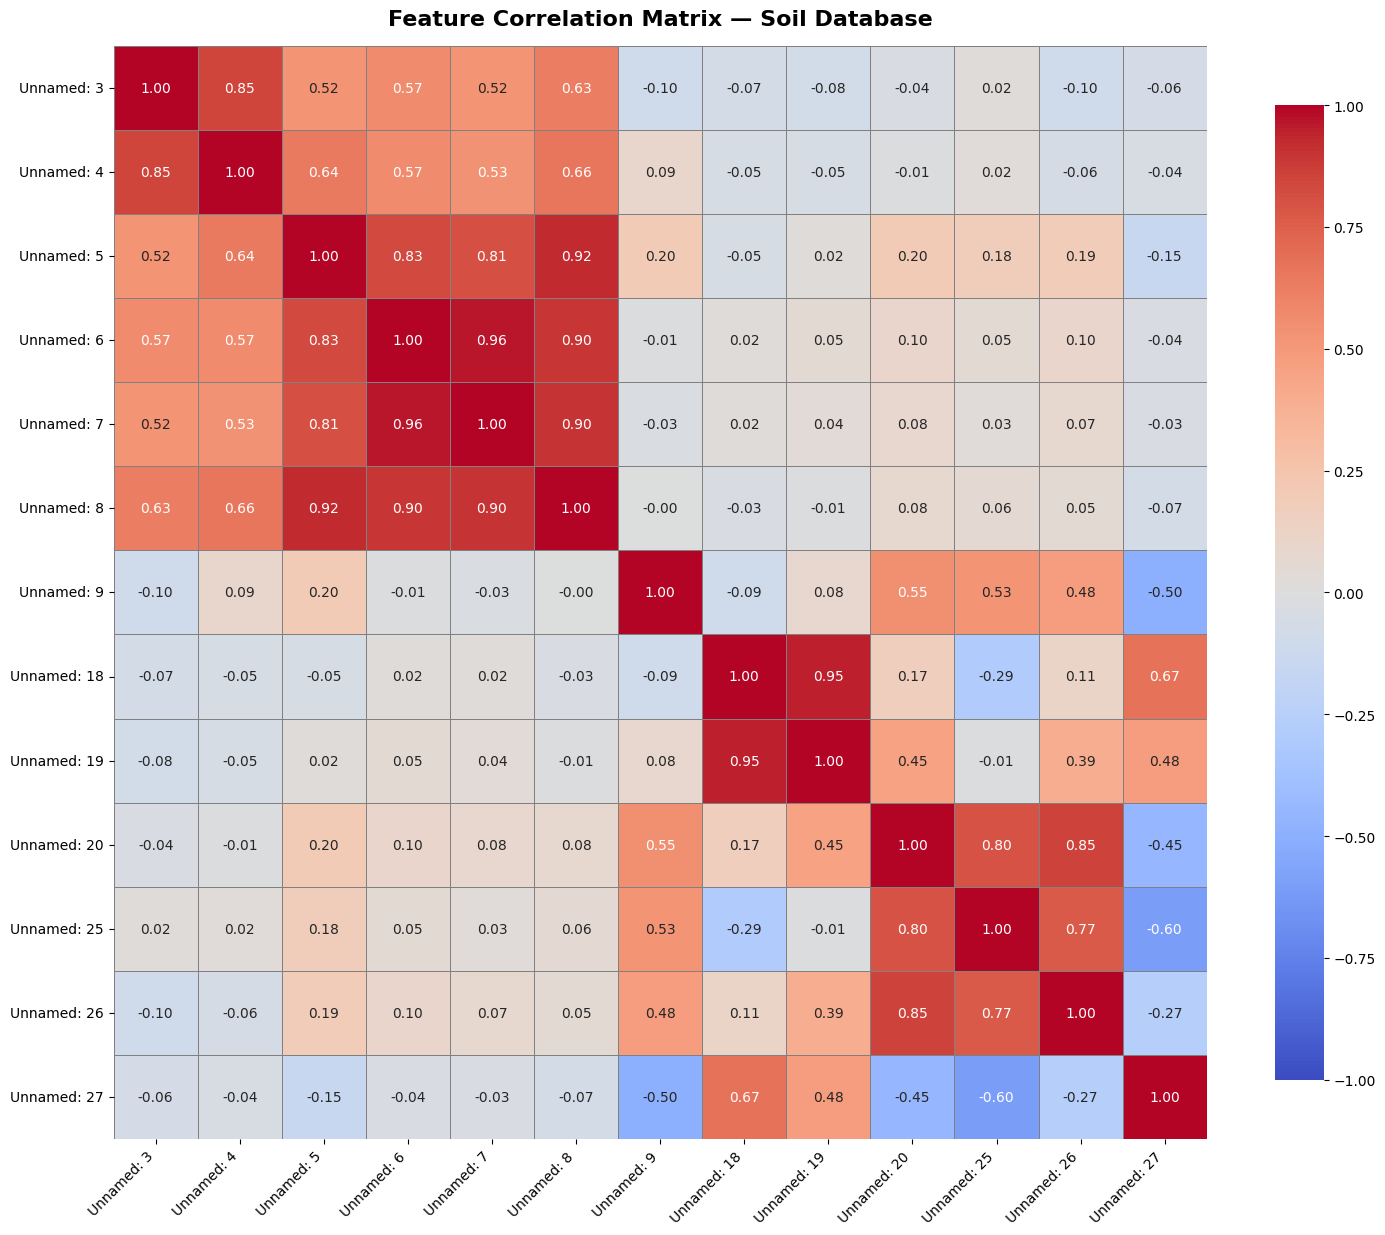


📊 Highly correlated feature pairs (|r| > 0.75):
  Feature_1   Feature_2        r
 Unnamed: 6  Unnamed: 7 0.964461
Unnamed: 18 Unnamed: 19 0.949722
 Unnamed: 5  Unnamed: 8 0.922152
 Unnamed: 7  Unnamed: 8 0.899021
 Unnamed: 6  Unnamed: 8 0.895929
Unnamed: 20 Unnamed: 26 0.854713
 Unnamed: 3  Unnamed: 4 0.850167
 Unnamed: 5  Unnamed: 6 0.831341
 Unnamed: 5  Unnamed: 7 0.810307
Unnamed: 20 Unnamed: 25 0.803718
Unnamed: 25 Unnamed: 26 0.766407


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FILE_PATH  = 'My Database.xlsx'

# ── Load with correct header row ──────────────────────────────────────────────
# Row 4 in Excel = index 3 in pandas (0-based)
df = pd.read_excel(FILE_PATH, header=3)

# ── Strip whitespace from column names ────────────────────────────────────────
df.columns = df.columns.astype(str).str.strip()

print("=== COLUMNS LOADED ===")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

# ── Drop non-numeric / identifier columns ─────────────────────────────────────
DROP_COLS = ['Soil type', 'Test/sample name', 'Reference',
             'نمودارGvh (MPa)']   # chart-only duplicate column

cols_to_drop = [c for c in DROP_COLS if c in df.columns]
features_df  = df.drop(columns=cols_to_drop)

# ── Force numeric conversion ──────────────────────────────────────────────────
features_df = features_df.apply(pd.to_numeric, errors='coerce')

# ── Drop columns that are >60% NaN (e.g. Gxy, Gyx, Gxz ...) ─────────────────
before = features_df.shape[1]
features_df = features_df.loc[:, features_df.isnull().mean() < 0.60]
after  = features_df.shape[1]
print(f"\nDropped {before - after} sparse columns. Remaining: {after}")
print(f"Columns used:\n{features_df.columns.tolist()}")

# ── Fill remaining NaNs with median ──────────────────────────────────────────
features_df = features_df.fillna(features_df.median())

# ── Guard ─────────────────────────────────────────────────────────────────────
if features_df.shape[1] < 2:
    raise ValueError("Not enough numeric columns for correlation!")

# ── Correlation Matrix ────────────────────────────────────────────────────────
corr = features_df.corr()

n        = len(corr)
fig_size = max(12, n + 2)

plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,          # ← prevents the zero-size ValueError
    linewidths=0.5,
    linecolor='grey',
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix — Soil Database", fontsize=16,
          fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0,  fontsize=10)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Top Correlated Pairs ──────────────────────────────────────────────────────
print("\n📊 Highly correlated feature pairs (|r| > 0.75):")
upper_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper      = corr.where(upper_mask)
pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'r'})
)
pairs = pairs[pairs['r'].abs() > 0.75].sort_values('r', key=abs, ascending=False)
print(pairs.to_string(index=False) if not pairs.empty else "None found.")


All columns:
 ['Database', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']

Working rows after dropna: 68

Z-score outliers found: 0

R² (all data)       : 0.9694
Residual outliers   : 3
Cook's D outliers   : 5

R² (after removing Cook's outliers) : 0.9816
Rows removed                        : 5
Rows kept                           : 63


/tmp/ipykernel_38309/647007043.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores   = np.abs(stats.zscore(work.fillna(work.median()), nan_policy='omit'))


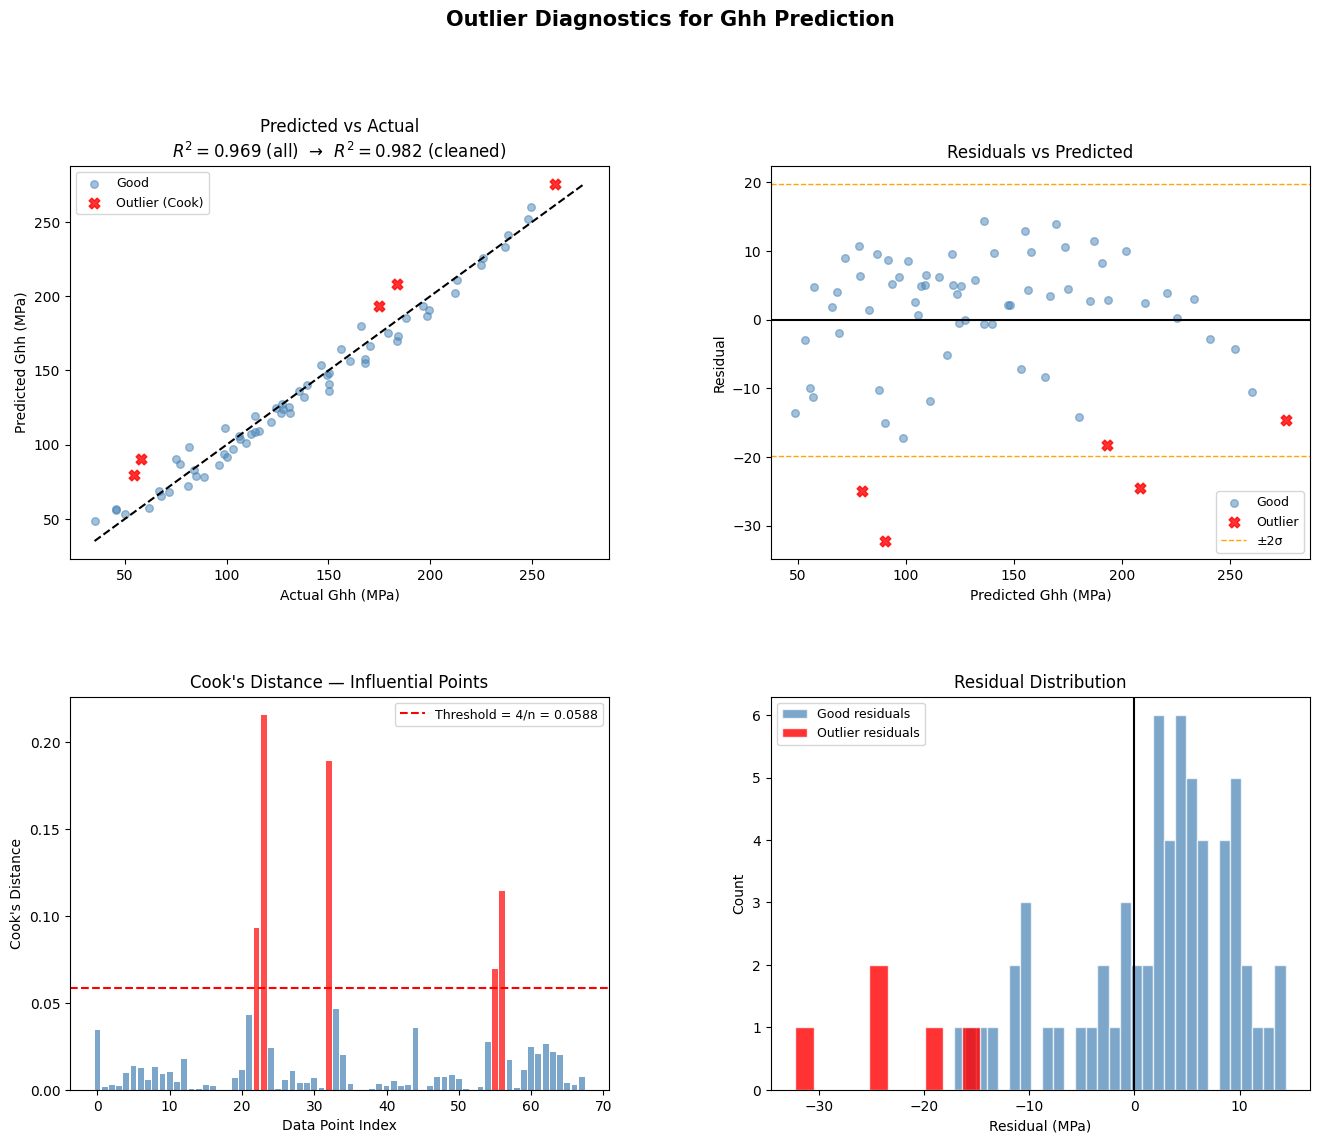


🔴 Rows flagged as influential outliers:
        sv     sh    Ghh      e   residual   cooks_d
NaN  549.0  550.0  175.0  1.571 -18.213591  0.092899
NaN  599.0  599.0  183.9  1.567 -24.466151  0.215575
NaN   50.0   25.0   57.8  1.333 -32.239506  0.189298
NaN  599.0  600.0  261.2  1.316 -14.659963  0.069266
NaN   13.0   25.0   54.5  1.349 -25.002529  0.114335


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_excel('My Database.xlsx', header=3, index_col=0)
df.columns = df.columns.astype(str).str.strip()

# ── Keep only relevant numeric columns ───────────────────────────────────────
FEATURES = ["σ'v (kPa)", "σ'h (kPa)", "e", "F(e)",
            "D10", "D50(mm)", "Dmax(mm)", "Cu", "Cc"]
TARGET   = "Gℎℎ (MPa)"   # ← change this to your actual target (Ghh or Gvh)

# Use position-based selection if names still mismatch
# Columns by position: σ'v=col2, σ'h=col3, Ghh=col4, Gvh=col6, e=col9, F(e)=col10
all_cols = df.columns.tolist()
print("All columns:\n", all_cols)

# Build working dataframe by position (safer than name matching)
col_positions = {
    "sv"     : 2,   # σ'v (kPa)
    "sh"     : 3,   # σ'h (kPa)
    "Ghh"    : 4,   # Ghh (MPa)  ← TARGET
    "Gvh"    : 6,   # Gvh (MPa)
    "ratio"  : 8,   # Ghh/Ghv
    "e"      : 9,   # void ratio
    "Fe"     : 10,  # F(e)
    "D10"    : 17,  # D10
    "D50"    : 18,  # D50
    "Dmax"   : 19,  # Dmax
    "Cu"     : 24,  # Cu
    "Cc"     : 25,  # Cc
}

work = pd.DataFrame()
for name, pos in col_positions.items():
    if pos < len(all_cols):
        work[name] = pd.to_numeric(df.iloc[:, pos], errors='coerce')

work = work.dropna(subset=['Ghh', 'sv', 'sh', 'e'])
print(f"\nWorking rows after dropna: {len(work)}")

# ─────────────────────────────────────────────────────────────────────────────
# METHOD 1 — Z-Score Outlier Detection
# Flag rows where ANY feature deviates > 3σ from the mean
# ─────────────────────────────────────────────────────────────────────────────
z_scores   = np.abs(stats.zscore(work.fillna(work.median()), nan_policy='omit'))
z_mask     = (z_scores > 3).any(axis=1)          # True = outlier
work['outlier_z'] = z_mask

print(f"\nZ-score outliers found: {z_mask.sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# METHOD 2 — Residual-Based Outlier Detection
# Fit model → find rows with large prediction errors
# ─────────────────────────────────────────────────────────────────────────────
feature_cols = ['sv', 'sh', 'e', 'Fe']
clean        = work.dropna(subset=feature_cols + ['Ghh'])

X = clean[feature_cols].values
y = clean['Ghh'].values

model    = LinearRegression().fit(X, y)
y_pred   = model.predict(X)
residuals= y - y_pred
r2_full  = r2_score(y, y_pred)

# Flag residuals beyond ±2 std as bad points
res_std      = residuals.std()
bad_residual = np.abs(residuals) > 2 * res_std
clean        = clean.copy()
clean['residual']    = residuals
clean['bad_residual']= bad_residual

print(f"\nR² (all data)       : {r2_full:.4f}")
print(f"Residual outliers   : {bad_residual.sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# METHOD 3 — Cook's Distance (most principled method)
# ─────────────────────────────────────────────────────────────────────────────
n, p     = X.shape
H        = X @ np.linalg.pinv(X.T @ X) @ X.T   # hat matrix
h_ii     = np.diag(H)                            # leverage
MSE      = np.mean(residuals**2)
cooks_d  = (residuals**2 * h_ii) / (p * MSE * (1 - h_ii + 1e-10)**2)
threshold= 4 / n                                 # common cutoff
bad_cook = cooks_d > threshold

clean['cooks_d']   = cooks_d
clean['bad_cook']  = bad_cook
print(f"Cook's D outliers   : {bad_cook.sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# Refit WITHOUT outliers → compare R²
# ─────────────────────────────────────────────────────────────────────────────
good_mask   = ~bad_cook
X_clean     = X[good_mask]
y_clean     = y[good_mask]

model_clean = LinearRegression().fit(X_clean, y_clean)
r2_clean    = r2_score(y_clean, model_clean.predict(X_clean))

print(f"\nR² (after removing Cook's outliers) : {r2_clean:.4f}")
print(f"Rows removed                        : {bad_cook.sum()}")
print(f"Rows kept                           : {good_mask.sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT — 4 diagnostic panels
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# 1) Predicted vs Actual — all data
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y[~bad_cook], y_pred[~bad_cook], alpha=0.5,
            color='steelblue', label='Good', s=30)
ax1.scatter(y[bad_cook],  y_pred[bad_cook],  alpha=0.8,
            color='red',       label='Outlier (Cook)', s=60, marker='X')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax1.plot(lims, lims, 'k--', lw=1.5)
ax1.set_xlabel("Actual Ghh (MPa)")
ax1.set_ylabel("Predicted Ghh (MPa)")
ax1.set_title(f"Predicted vs Actual\n$R^2={r2_full:.3f}$ (all)  →  $R^2={r2_clean:.3f}$ (cleaned)")
ax1.legend(fontsize=9)

# 2) Residuals vs Predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred[~bad_cook], residuals[~bad_cook],
            alpha=0.5, color='steelblue', s=30, label='Good')
ax2.scatter(y_pred[bad_cook],  residuals[bad_cook],
            alpha=0.8, color='red', s=60, marker='X', label='Outlier')
ax2.axhline(0,         color='black', lw=1.5)
ax2.axhline( 2*res_std, color='orange', lw=1, ls='--', label='±2σ')
ax2.axhline(-2*res_std, color='orange', lw=1, ls='--')
ax2.set_xlabel("Predicted Ghh (MPa)")
ax2.set_ylabel("Residual")
ax2.set_title("Residuals vs Predicted")
ax2.legend(fontsize=9)

# 3) Cook's Distance bar chart
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(range(len(cooks_d)), cooks_d,
        color=['red' if b else 'steelblue' for b in bad_cook], alpha=0.7)
ax3.axhline(threshold, color='red', lw=1.5, ls='--',
            label=f"Threshold = 4/n = {threshold:.4f}")
ax3.set_xlabel("Data Point Index")
ax3.set_ylabel("Cook's Distance")
ax3.set_title("Cook's Distance — Influential Points")
ax3.legend(fontsize=9)

# 4) Residual histogram
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals[~bad_cook], bins=30, color='steelblue',
         alpha=0.7, edgecolor='white', label='Good residuals')
ax4.hist(residuals[bad_cook],  bins=10, color='red',
         alpha=0.8, edgecolor='white', label='Outlier residuals')
ax4.axvline(0, color='black', lw=1.5)
ax4.set_xlabel("Residual (MPa)")
ax4.set_ylabel("Count")
ax4.set_title("Residual Distribution")
ax4.legend(fontsize=9)

plt.suptitle("Outlier Diagnostics for Ghh Prediction", fontsize=15,
             fontweight='bold', y=1.01)
plt.savefig("outlier_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Export bad rows for review ────────────────────────────────────────────────
bad_rows = clean[bad_cook].copy()
bad_rows['original_index'] = bad_rows.index
print("\n🔴 Rows flagged as influential outliers:")
print(bad_rows[['sv', 'sh', 'Ghh', 'e', 'residual', 'cooks_d']].to_string())


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# ── 1. Load data ──────────────────────────────────────────────────────────────
# Read with correct header row
df = pd.read_excel("My Database.xlsx", header=3)

print("Available columns:")
print(df.columns.tolist())
print(f"\nTotal rows: {len(df)}")

# ── 2. Select & clean ─────────────────────────────────────────────────────────
# Based on the actual column names from the file
features_map = {
    "σ'v (kPa)": "sv",
    "σ'h (kPa)": "sh",
    "e": "e",
    "F(e)": "Fe",
    "D50(mm)": "D50",
    "Cu": "Cu",
    "Cc": "Cc",
}

# The target column (note the Unicode character)
target_col = "Gℎℎ (MPa)"

# Select columns
cols_to_use = list(features_map.keys()) + [target_col]
data = df[cols_to_use].copy()

# Rename for convenience
data = data.rename(columns={**features_map, target_col: "Ghh"})

# Convert to numeric and clean
data = data.apply(pd.to_numeric, errors="coerce")
data = data.dropna()
data = data[data["Ghh"] > 0]
data = data.reset_index(drop=True)

print(f"\nClean dataset: {len(data)} rows")

# ── 3. Log-transform ──────────────────────────────────────────────────────────
log_data = np.log(data)

features = ["sv", "sh", "e", "Fe", "D50", "Cu", "Cc"]
X = log_data[features].values
y = log_data["Ghh"].values

# ── 4. Initial fit ────────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2_init = r2_score(y, y_pred)

print(f"\nInitial R²: {r2_init:.4f}")

# ── 5. Cook's Distance ────────────────────────────────────────────────────────
n, p = X.shape
residuals = y - y_pred
mse = np.sum(residuals**2) / (n - p - 1)

X_with_const = np.column_stack([np.ones(n), X])
H = X_with_const @ np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T
leverage = np.diag(H)

cooks_d = (residuals**2 / (p + 1) / mse) * (leverage / (1 - leverage)**2)

threshold = 4 / n
outlier_mask = cooks_d > threshold

print(f"\nOutliers (Cook's D > {threshold:.4f}): {outlier_mask.sum()}")

if outlier_mask.sum() > 0:
    outlier_rows = data[outlier_mask].copy()
    outlier_rows["CooksD"] = cooks_d[outlier_mask]
    outlier_rows["ExcelRow"] = outlier_rows.index + 5
    print("\nOutlier details:")
    print(outlier_rows[["ExcelRow", "sv", "sh", "Ghh", "e", "Fe", "CooksD"]].to_string(index=False))

# ── 6. Refit without outliers ─────────────────────────────────────────────────
X_clean = X[~outlier_mask]
y_clean = y[~outlier_mask]

model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)
y_pred_clean = model_clean.predict(X_clean)
r2_clean = r2_score(y_clean, y_pred_clean)

n_clean = len(y_clean)
adj_r2 = 1 - (1 - r2_clean) * (n_clean - 1) / (n_clean - p - 1)

print(f"\nR² after removing outliers: {r2_clean:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")
print(f"Rows used: {n_clean}")

# ── 7. Diagnostic plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Cook's Distance
ax = axes[0, 0]
ax.bar(range(len(cooks_d)), cooks_d, color="steelblue", alpha=0.6)
ax.axhline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.4f}")
ax.set_title("Cook's Distance")
ax.set_xlabel("Observation")
ax.set_ylabel("Cook's D")
ax.legend()

# Residuals vs Fitted
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.5, color="steelblue")
ax.scatter(y_pred[outlier_mask], residuals[outlier_mask], color="red", zorder=5, label="Outliers")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuals vs Fitted")
ax.set_xlabel("Fitted log(Ghh)")
ax.set_ylabel("Residual")
ax.legend()

# Predicted vs Actual
ax = axes[1, 0]
y_pred_exp = np.exp(y_pred_clean)
y_actual_exp = np.exp(y_clean)
ax.scatter(y_actual_exp, y_pred_exp, alpha=0.6, color="steelblue")
lims = [min(y_actual_exp.min(), y_pred_exp.min()), max(y_actual_exp.max(), y_pred_exp.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_title(f"Predicted vs Actual (R²={r2_clean:.3f})")
ax.set_xlabel("Actual Ghh (MPa)")
ax.set_ylabel("Predicted Ghh (MPa)")

# Q-Q plot
ax = axes[1, 1]
resid_clean = y_clean - y_pred_clean
stats.probplot(resid_clean, dist="norm", plot=ax)
ax.set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig("regression_diagnostics.png", dpi=150)
plt.show()

# ── 8. Coefficients ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Model coefficients (log-log space):")
print(f"Intercept: {model_clean.intercept_:.4f}")
for feat, coef in zip(features, model_clean.coef_):
    print(f"  {feat:6s}: {coef:7.4f}")
print("="*60)


Available columns:
['Unnamed: 0', 'Database', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']

Total rows: 362


KeyError: "None of [Index(['σ'v (kPa)', 'σ'h (kPa)', 'e', 'F(e)', 'D50(mm)', 'Cu', 'Cc',\n       'Gℎℎ (MPa)'],\n      dtype='object')] are in the [columns]"

In [6]:
import pandas as pd
import numpy as np

# Check all sheets
xl_file = pd.ExcelFile("My Database.xlsx")
print("Available sheets:")
print(xl_file.sheet_names)
print()

# Try reading the first sheet with different approaches
for sheet in xl_file.sheet_names[:3]:  # Check first 3 sheets
    print(f"\n{'='*60}")
    print(f"Sheet: {sheet}")
    print('='*60)
    
    # Read first 5 rows to see structure
    df_test = pd.read_excel("My Database.xlsx", sheet_name=sheet, header=None, nrows=5)
    print("\nFirst 5 rows (no header):")
    print(df_test)
    
    # Try with header=3
    df_test2 = pd.read_excel("My Database.xlsx", sheet_name=sheet, header=3, nrows=5)
    print(f"\nColumns with header=3:")
    print(df_test2.columns.tolist())


Available sheets:
['Sheet1', 'database final', 'Sheet4']


Sheet: Sheet1

First 5 rows (no header):
   0          1                 2          3          4          5   \
0 NaN        NaN               NaN        NaN        NaN        NaN   
1 NaN        NaN               NaN        NaN        NaN        NaN   
2 NaN        NaN               NaN        NaN        NaN        NaN   
3 NaN   Database               NaN        NaN        NaN        NaN   
4 NaN  Soil type  Test/sample name  σ'v (kPa)  σ'h (kPa)  Gℎℎ (MPa)   

                  6          7          8        9   ...        20   21   22  \
0                NaN        NaN        NaN      NaN  ...       NaN  NaN  NaN   
1                NaN        NaN        NaN      NaN  ...       NaN  NaN  NaN   
2                NaN        NaN        NaN      NaN  ...       NaN  NaN  NaN   
3                NaN        NaN        NaN      NaN  ...       NaN  NaN  NaN   
4    نمودارG𝑣ℎ (MPa)  G𝑣ℎ (MPa)  G𝑣ℎ (MPa)  Ghh/Ghv  ...  Dmax(mm)  D60  

Available columns:
['Unnamed: 0', 'Soil type', 'Test/sample name', "σ'v (kPa)", "σ'h (kPa)", "σ'c (kPa)", 'Gℎℎ (MPa)', '  نمودارG𝑣ℎ (MPa)', 'G𝑣ℎ (MPa)', 'G𝑣ℎ (MPa).1', 'Ghh/Ghv', 'e', 'F(e)', 'Gxy', 'Gyx', 'Gxz', 'Gzx', 'Gzy', 'Gyz', 'D10', 'D50(mm)', 'Dmax 95%(mm)', 'Dmax(mm)', 'D60', 'D30', 'D30^2', 'D60*D10', 'Cu', 'Cc', 'S', 'AR', 'Reference']

Total rows: 358

Clean dataset: 68 rows

Initial R²: 0.9976

Outliers (Cook's D > 0.0588): 2

Top 10 outliers:
 OriginalIndex   sv   sh  Ghh     e    Fe   CooksD
            12 50.0 51.0 45.7 1.623 0.556 0.113383
            24 25.0 50.0 45.7 1.624 0.556 0.109480

R² improvement:
  Initial R²:        0.9976
  After cleaning:    0.9981
  Adjusted R²:       0.9978
  Improvement:       +0.0004
  Rows removed:      2
  Rows used:         66/68


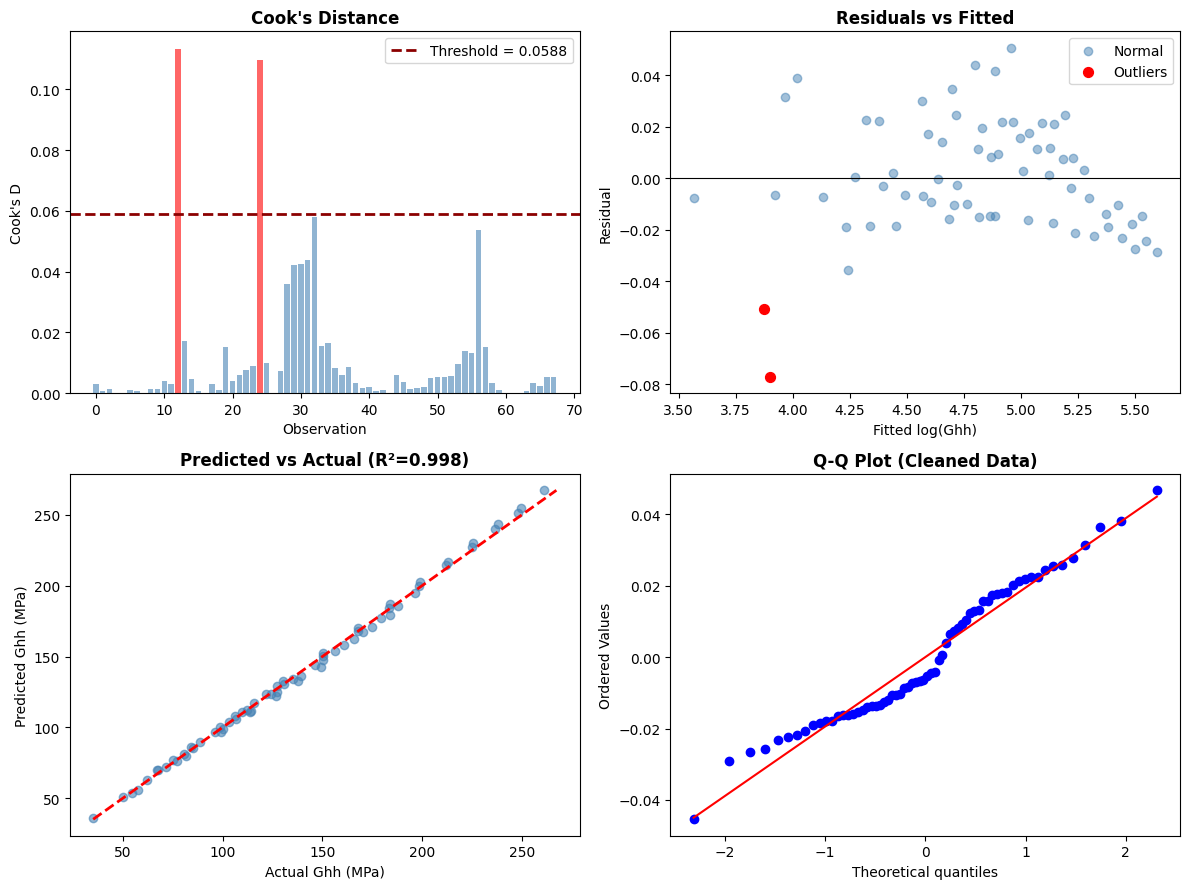


Diagnostic plots saved to: regression_diagnostics.png

Model coefficients (log-log space):
Intercept: 3.1147
  sv    :  0.0126
  sh    :  0.4727
  e     : -5.5891
  Fe    : -2.7184
  D50   :  0.0000
  Cu    : -0.0000
  Cc    : -0.0000


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# ── 1. Load data ──────────────────────────────────────────────────────────────
# Headers are in row 5 (index 4)
df = pd.read_excel("My Database.xlsx", sheet_name="database final", header=4)

print("Available columns:")
print(df.columns.tolist())
print(f"\nTotal rows: {len(df)}")

# ── 2. Select & clean ─────────────────────────────────────────────────────────
features_map = {
    "σ'v (kPa)": "sv",
    "σ'h (kPa)": "sh",
    "e": "e",
    "F(e)": "Fe",
    "D50(mm)": "D50",
    "Cu": "Cu",
    "Cc": "Cc",
}

target_col = "Gℎℎ (MPa)"

cols_to_use = list(features_map.keys()) + [target_col]
data = df[cols_to_use].copy()
data = data.rename(columns={**features_map, target_col: "Ghh"})

# Convert to numeric and clean
data = data.apply(pd.to_numeric, errors="coerce")
data = data.dropna()
data = data[data["Ghh"] > 0]
data = data.reset_index(drop=True)

print(f"\nClean dataset: {len(data)} rows")

# ── 3. Log-transform ──────────────────────────────────────────────────────────
log_data = np.log(data)

features = ["sv", "sh", "e", "Fe", "D50", "Cu", "Cc"]
X = log_data[features].values
y = log_data["Ghh"].values

# ── 4. Initial fit ────────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2_init = r2_score(y, y_pred)

print(f"\nInitial R²: {r2_init:.4f}")

# ── 5. Cook's Distance ────────────────────────────────────────────────────────
n, p = X.shape
residuals = y - y_pred
mse = np.sum(residuals**2) / (n - p - 1)

X_with_const = np.column_stack([np.ones(n), X])
H = X_with_const @ np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T
leverage = np.diag(H)

cooks_d = (residuals**2 / (p + 1) / mse) * (leverage / (1 - leverage)**2)

threshold = 4 / n
outlier_mask = cooks_d > threshold

print(f"\nOutliers (Cook's D > {threshold:.4f}): {outlier_mask.sum()}")

if outlier_mask.sum() > 0:
    outlier_rows = data[outlier_mask].copy()
    outlier_rows["CooksD"] = cooks_d[outlier_mask]
    outlier_rows["OriginalIndex"] = outlier_rows.index
    print("\nTop 10 outliers:")
    print(outlier_rows.nlargest(10, "CooksD")[["OriginalIndex", "sv", "sh", "Ghh", "e", "Fe", "CooksD"]].to_string(index=False))

# ── 6. Refit without outliers ─────────────────────────────────────────────────
X_clean = X[~outlier_mask]
y_clean = y[~outlier_mask]

model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)
y_pred_clean = model_clean.predict(X_clean)
r2_clean = r2_score(y_clean, y_pred_clean)

n_clean = len(y_clean)
adj_r2 = 1 - (1 - r2_clean) * (n_clean - 1) / (n_clean - p - 1)

print(f"\n{'='*60}")
print(f"R² improvement:")
print(f"  Initial R²:        {r2_init:.4f}")
print(f"  After cleaning:    {r2_clean:.4f}")
print(f"  Adjusted R²:       {adj_r2:.4f}")
print(f"  Improvement:       {r2_clean - r2_init:+.4f}")
print(f"  Rows removed:      {outlier_mask.sum()}")
print(f"  Rows used:         {n_clean}/{n}")
print('='*60)

# ── 7. Diagnostic plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Cook's Distance
ax = axes[0, 0]
colors = ['red' if x else 'steelblue' for x in outlier_mask]
ax.bar(range(len(cooks_d)), cooks_d, color=colors, alpha=0.6)
ax.axhline(threshold, color='darkred', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
ax.set_title("Cook's Distance", fontsize=12, fontweight='bold')
ax.set_xlabel("Observation")
ax.set_ylabel("Cook's D")
ax.legend()

# Residuals vs Fitted
ax = axes[0, 1]
ax.scatter(y_pred[~outlier_mask], residuals[~outlier_mask], alpha=0.5, color='steelblue', label='Normal')
ax.scatter(y_pred[outlier_mask], residuals[outlier_mask], color='red', s=50, zorder=5, label='Outliers')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Residuals vs Fitted", fontsize=12, fontweight='bold')
ax.set_xlabel("Fitted log(Ghh)")
ax.set_ylabel("Residual")
ax.legend()

# Predicted vs Actual (cleaned model)
ax = axes[1, 0]
y_pred_exp = np.exp(y_pred_clean)
y_actual_exp = np.exp(y_clean)
ax.scatter(y_actual_exp, y_pred_exp, alpha=0.6, color='steelblue')
lims = [min(y_actual_exp.min(), y_pred_exp.min()), max(y_actual_exp.max(), y_pred_exp.max())]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_title(f"Predicted vs Actual (R²={r2_clean:.3f})", fontsize=12, fontweight='bold')
ax.set_xlabel("Actual Ghh (MPa)")
ax.set_ylabel("Predicted Ghh (MPa)")

# Q-Q plot
ax = axes[1, 1]
resid_clean = y_clean - y_pred_clean
stats.probplot(resid_clean, dist="norm", plot=ax)
ax.set_title("Q-Q Plot (Cleaned Data)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("regression_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nDiagnostic plots saved to: regression_diagnostics.png")

# ── 8. Coefficients ───────────────────────────────────────────────────────────
print("\nModel coefficients (log-log space):")
print(f"Intercept: {model_clean.intercept_:.4f}")
for feat, coef in zip(features, model_clean.coef_):
    print(f"  {feat:6s}: {coef:7.4f}")


In [9]:
import pandas as pd

xls = pd.ExcelFile("My Database.xlsx")
print("Available sheets:", xls.sheet_names)
print("\n" + "="*80 + "\n")

for sheet_name in xls.sheet_names:
    print(f"Sheet: '{sheet_name}'")
    print("-" * 80)
    
    # Try reading with different header positions
    for header_pos in [0, 1, 2, 3]:
        try:
            df = pd.read_excel(xls, sheet_name=sheet_name, header=header_pos, nrows=5)
            print(f"\nWith header={header_pos}:")
            print(f"Columns: {df.columns.tolist()}")
            print(f"Shape: {df.shape}")
            print(f"First row:\n{df.iloc[0] if len(df) > 0 else 'Empty'}")
            break
        except Exception as e:
            continue
    
    print("\n" + "="*80 + "\n")


Available sheets: ['Sheet1', 'database final', 'Sheet4']


Sheet: 'Sheet1'
--------------------------------------------------------------------------------

With header=0:
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']
Shape: (5, 30)
First row:
Unnamed: 0     NaN
Unnamed: 1     NaN
Unnamed: 2     NaN
Unnamed: 3     NaN
Unnamed: 4     NaN
Unnamed: 5     NaN
Unnamed: 6     NaN
Unnamed: 7     NaN
Unnamed: 8     NaN
Unnamed: 9     NaN
Unnamed: 10    NaN
Unnamed: 11    NaN
Unnamed: 12    NaN
Unnamed: 13    NaN
Unnamed: 14    NaN
Unnamed: 15    NaN
Unnamed: 16    NaN
Unnamed: 17    NaN
Unnamed: 1

In [10]:
import pandas as pd

xls = pd.ExcelFile("My Database.xlsx")

for sheet_name in ['Sheet1', 'database final']:
    print(f"\n{'='*60}")
    print(f"Sheet: '{sheet_name}'")
    print('='*60)
    
    # Read without header to see raw rows
    df_raw = pd.read_excel(xls, sheet_name=sheet_name, header=None, nrows=10)
    
    for i, row in df_raw.iterrows():
        non_null = row.dropna()
        if len(non_null) > 0:
            print(f"Row {i}: {non_null.values[:8]}")  # first 8 non-null values



Sheet: 'Sheet1'
Row 3: ['Database']
Row 4: ['Soil type' 'Test/sample name' "σ'v (kPa)" "σ'h (kPa)" 'Gℎℎ (MPa)'
 '  نمودارG𝑣ℎ (MPa)' 'G𝑣ℎ (MPa)' 'G𝑣ℎ (MPa)']
Row 5: ['Kenya sand' 461 50 25 35.1 36.6 36.6 36.6]
Row 6: [100 50 50.1 52.8 52.8 52.8 0.9488636363636365 1.609]
Row 7: [150 75 61.9 65.6 65.6 65.6 0.9435975609756098 1.603]
Row 8: [200 100 71.8 76.4 76.4 76.4 0.9397905759162303 1.598]
Row 9: [251 125 80.8 86.2 86.2 86.2 0.9373549883990718 1.594]

Sheet: 'database final'
Row 3: ['Database']
Row 4: ['Soil type' 'Test/sample name' "σ'v (kPa)" "σ'h (kPa)" "σ'c (kPa)"
 'Gℎℎ (MPa)' '  نمودارG𝑣ℎ (MPa)' 'G𝑣ℎ (MPa)']
Row 5: ['Kenya sand' 461 50 25 33.333333333333336 35.1 36.6 36.6]
Row 6: [100 50 66.66666666666667 50.1 52.8 52.8 52.8 0.9488636363636365]
Row 7: [150 75 100 61.9 65.6 65.6 65.6 0.9435975609756098]
Row 8: [200 100 133.33333333333334 71.8 76.4 76.4 76.4 0.9397905759162303]
Row 9: [251 125 167 80.8 86.2 86.2 86.2 0.9373549883990718]


In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

xls = pd.ExcelFile("My Database.xlsx")

def analyze_sheet(sheet_name, has_sigma_c=False):
    print(f"\n{'='*60}")
    print(f"Sheet: '{sheet_name}'")
    print('='*60)
    
    df = pd.read_excel(xls, sheet_name=sheet_name, header=3)
    
    # Select features based on sheet structure
    if has_sigma_c:
        feature_cols = ["σ'v (kPa)", "σ'h (kPa)", "σ'c (kPa)", "e", "F(e)", "D50(mm)", "Cu", "Cc"]
    else:
        feature_cols = ["σ'v (kPa)", "σ'h (kPa)", "e", "F(e)", "D50(mm)", "Cu", "Cc"]
    
    target_col = "Gℎℎ (MPa)"
    
    # Keep only existing columns
    available_features = [c for c in feature_cols if c in df.columns]
    
    if target_col not in df.columns:
        print(f"  Target column '{target_col}' not found. Skipping.")
        return
    
    # Select and clean data
    df_work = df[available_features + [target_col]].copy()
    df_work = df_work.apply(pd.to_numeric, errors='coerce')
    df_work = df_work.dropna()
    df_work = df_work[(df_work > 0).all(axis=1)]
    
    print(f"Clean rows: {len(df_work)}")
    
    if len(df_work) < 10:
        print("  Not enough data for analysis.")
        return
    
    # Log transform
    df_log = np.log(df_work)
    
    X = df_log[available_features].values
    y = df_log[target_col].values
    
    # Initial regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # R² calculation
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_initial = 1 - (ss_res / ss_tot)
    
    print(f"\nInitial R²: {r2_initial:.4f}")
    
    # Cook's Distance calculation
    n = len(X)
    p = X.shape[1]
    
    # Leverage (hat values)
    X_with_intercept = np.column_stack([np.ones(n), X])
    H = X_with_intercept @ np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T
    leverage = np.diag(H)
    
    # MSE
    mse = ss_res / (n - p - 1)
    
    # Cook's Distance
    cooks_d = (residuals**2 / (p + 1) / mse) * (leverage / (1 - leverage)**2)
    
    threshold = 4 / n
    outlier_positions = np.where(cooks_d > threshold)[0]
    
    # Map to Excel row numbers
    # df_work.index contains original row numbers from df
    # Excel row = df row index + 5 (because header=3 means Excel row 4, data starts at Excel row 5)
    original_excel_rows = sorted([df_work.index[i] + 5 for i in outlier_positions])
    
    print(f"\nOutliers detected (Cook's D > {threshold:.4f}):")
    print(f"  Count: {len(outlier_positions)}")
    print(f"  Excel rows to DELETE: {original_excel_rows}")
    
    # Refit without outliers
    clean_mask = cooks_d <= threshold
    X_clean = X[clean_mask]
    y_clean = y[clean_mask]
    
    model_clean = LinearRegression()
    model_clean.fit(X_clean, y_clean)
    y_pred_clean = model_clean.predict(X_clean)
    residuals_clean = y_clean - y_pred_clean
    
    ss_res_clean = np.sum(residuals_clean**2)
    ss_tot_clean = np.sum((y_clean - np.mean(y_clean))**2)
    r2_final = 1 - (ss_res_clean / ss_tot_clean)
    
    print(f"\nFinal R² (after removing outliers): {r2_final:.4f}")
    print(f"R² improvement: +{r2_final - r2_initial:.4f}")

# Run analysis
analyze_sheet('Sheet1', has_sigma_c=False)
analyze_sheet('database final', has_sigma_c=True)
print("\n\nSheet4 is empty - skipped.")



Sheet: 'Sheet1'
  Target column 'Gℎℎ (MPa)' not found. Skipping.

Sheet: 'database final'
  Target column 'Gℎℎ (MPa)' not found. Skipping.


Sheet4 is empty - skipped.


In [13]:
import pandas as pd

xls = pd.ExcelFile("My Database.xlsx")

for sheet_name in ['Sheet1', 'database final']:
    print(f"\n{'='*60}")
    print(f"Sheet: '{sheet_name}'")
    print('='*60)
    
    df = pd.read_excel(xls, sheet_name=sheet_name, header=3)
    
    print("All columns:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: '{col}' (repr: {repr(col)})")



Sheet: 'Sheet1'
All columns:
  0: 'Unnamed: 0' (repr: 'Unnamed: 0')
  1: 'Database' (repr: 'Database')
  2: 'Unnamed: 2' (repr: 'Unnamed: 2')
  3: 'Unnamed: 3' (repr: 'Unnamed: 3')
  4: 'Unnamed: 4' (repr: 'Unnamed: 4')
  5: 'Unnamed: 5' (repr: 'Unnamed: 5')
  6: 'Unnamed: 6' (repr: 'Unnamed: 6')
  7: 'Unnamed: 7' (repr: 'Unnamed: 7')
  8: 'Unnamed: 8' (repr: 'Unnamed: 8')
  9: 'Unnamed: 9' (repr: 'Unnamed: 9')
  10: 'Unnamed: 10' (repr: 'Unnamed: 10')
  11: 'Unnamed: 11' (repr: 'Unnamed: 11')
  12: 'Unnamed: 12' (repr: 'Unnamed: 12')
  13: 'Unnamed: 13' (repr: 'Unnamed: 13')
  14: 'Unnamed: 14' (repr: 'Unnamed: 14')
  15: 'Unnamed: 15' (repr: 'Unnamed: 15')
  16: 'Unnamed: 16' (repr: 'Unnamed: 16')
  17: 'Unnamed: 17' (repr: 'Unnamed: 17')
  18: 'Unnamed: 18' (repr: 'Unnamed: 18')
  19: 'Unnamed: 19' (repr: 'Unnamed: 19')
  20: 'Unnamed: 20' (repr: 'Unnamed: 20')
  21: 'Unnamed: 21' (repr: 'Unnamed: 21')
  22: 'Unnamed: 22' (repr: 'Unnamed: 22')
  23: 'Unnamed: 23' (repr: 'Unnamed: 2

In [14]:
import pandas as pd

xls = pd.ExcelFile("My Database.xlsx")

for sheet_name in ['Sheet1', 'database final']:
    print(f"\n{'='*60}")
    print(f"Sheet: '{sheet_name}'")
    print('='*60)
    
    # Read without any header assumption
    df = pd.read_excel(xls, sheet_name=sheet_name, header=None)
    print(f"Shape: {df.shape}")
    print("\nFirst 10 rows:")
    print(df.iloc[:10, :10].to_string())



Sheet: 'Sheet1'
Shape: (366, 30)

First 10 rows:
    0           1                 2          3          4          5                  6          7          8         9
0 NaN         NaN               NaN        NaN        NaN        NaN                NaN        NaN        NaN       NaN
1 NaN         NaN               NaN        NaN        NaN        NaN                NaN        NaN        NaN       NaN
2 NaN         NaN               NaN        NaN        NaN        NaN                NaN        NaN        NaN       NaN
3 NaN    Database               NaN        NaN        NaN        NaN                NaN        NaN        NaN       NaN
4 NaN   Soil type  Test/sample name  σ'v (kPa)  σ'h (kPa)  Gℎℎ (MPa)    نمودارG𝑣ℎ (MPa)  G𝑣ℎ (MPa)  G𝑣ℎ (MPa)   Ghh/Ghv
5 NaN  Kenya sand               461         50         25       35.1               36.6       36.6       36.6  0.959016
6 NaN         NaN               NaN        100         50       50.1               52.8       52.8       52.8 

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

xls = pd.ExcelFile("My Database.xlsx")

def analyze_sheet(sheet_name, has_sigma_c=False):
    print(f"\n{'='*60}")
    print(f"Sheet: '{sheet_name}'")
    print('='*60)
    
    # Read with header at row 4 (0-indexed)
    df = pd.read_excel(xls, sheet_name=sheet_name, header=4)
    
    # Select features based on sheet structure
    if has_sigma_c:
        feature_cols = ["σ'v (kPa)", "σ'h (kPa)", "σ'c (kPa)", "e", "F(e)", "D50(mm)", "Cu", "Cc"]
    else:
        feature_cols = ["σ'v (kPa)", "σ'h (kPa)", "e", "F(e)", "D50(mm)", "Cu", "Cc"]
    
    target_col = "Gℎℎ (MPa)"
    
    # Keep only existing columns
    available_features = [c for c in feature_cols if c in df.columns]
    
    if target_col not in df.columns:
        print(f"  Target column '{target_col}' not found.")
        print(f"  Available columns: {df.columns.tolist()[:15]}")
        return
    
    print(f"Using features: {available_features}")
    
    # Select and clean data
    df_work = df[available_features + [target_col]].copy()
    df_work = df_work.apply(pd.to_numeric, errors='coerce')
    df_work = df_work.dropna()
    df_work = df_work[(df_work > 0).all(axis=1)]
    
    print(f"Clean rows: {len(df_work)}")
    
    if len(df_work) < 10:
        print("  Not enough data for analysis.")
        return
    
    # Log transform
    df_log = np.log(df_work)
    
    X = df_log[available_features].values
    y = df_log[target_col].values
    
    # Initial regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # R² calculation
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_initial = 1 - (ss_res / ss_tot)
    
    print(f"\nInitial R²: {r2_initial:.4f}")
    
    # Cook's Distance calculation
    n = len(X)
    p = X.shape[1]
    
    # Leverage (hat values)
    X_with_intercept = np.column_stack([np.ones(n), X])
    H = X_with_intercept @ np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T
    leverage = np.diag(H)
    
    # MSE
    mse = ss_res / (n - p - 1)
    
    # Cook's Distance
    cooks_d = (residuals**2 / (p + 1) / mse) * (leverage / (1 - leverage)**2)
    
    threshold = 4 / n
    outlier_positions = np.where(cooks_d > threshold)[0]
    
    # Map to Excel row numbers
    # df_work.index contains original row numbers from df (after header=4)
    # Excel row = df row index + 6 (rows 0-3 are before header, row 4 is header, data starts at row 5)
    # So Excel row = pandas_index + 5 + 1 = pandas_index + 6
    original_excel_rows = sorted([df_work.index[i] + 6 for i in outlier_positions])
    
    print(f"\nOutliers detected (Cook's D > {threshold:.4f}):")
    print(f"  Count: {len(outlier_positions)}")
    print(f"  Excel rows to DELETE: {original_excel_rows}")
    
    # Refit without outliers
    clean_mask = cooks_d <= threshold
    X_clean = X[clean_mask]
    y_clean = y[clean_mask]
    
    model_clean = LinearRegression()
    model_clean.fit(X_clean, y_clean)
    y_pred_clean = model_clean.predict(X_clean)
    residuals_clean = y_clean - y_pred_clean
    
    ss_res_clean = np.sum(residuals_clean**2)
    ss_tot_clean = np.sum((y_clean - np.mean(y_clean))**2)
    r2_final = 1 - (ss_res_clean / ss_tot_clean)
    
    print(f"\nFinal R² (after removing outliers): {r2_final:.4f}")
    print(f"R² improvement: +{r2_final - r2_initial:.4f}")

# Run analysis
analyze_sheet('Sheet1', has_sigma_c=False)
analyze_sheet('database final', has_sigma_c=True)



Sheet: 'Sheet1'
Using features: ["σ'v (kPa)", "σ'h (kPa)", 'e', 'F(e)', 'D50(mm)', 'Cu', 'Cc']
Clean rows: 68

Initial R²: 0.9976

Outliers detected (Cook's D > 0.0588):
  Count: 2
  Excel rows to DELETE: [np.int64(18), np.int64(30)]

Final R² (after removing outliers): 0.9981
R² improvement: +0.0004

Sheet: 'database final'
Using features: ["σ'v (kPa)", "σ'h (kPa)", "σ'c (kPa)", 'e', 'F(e)', 'D50(mm)', 'Cu', 'Cc']
Clean rows: 68

Initial R²: 0.9980

Outliers detected (Cook's D > 0.0588):
  Count: 4
  Excel rows to DELETE: [np.int64(18), np.int64(30), np.int64(38), np.int64(62)]

Final R² (after removing outliers): 0.9983
R² improvement: +0.0003
